In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

sns.set_style("whitegrid")
np.random.seed(42)


## Load data

In [ ]:
df = pd.read_csv("iris.csv")
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

df.head()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.describe()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
df["Species"].value_counts()


,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


## EDA

/tmp/ipykernel_2760/1935415288.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Species", data=df, palette="viridis")


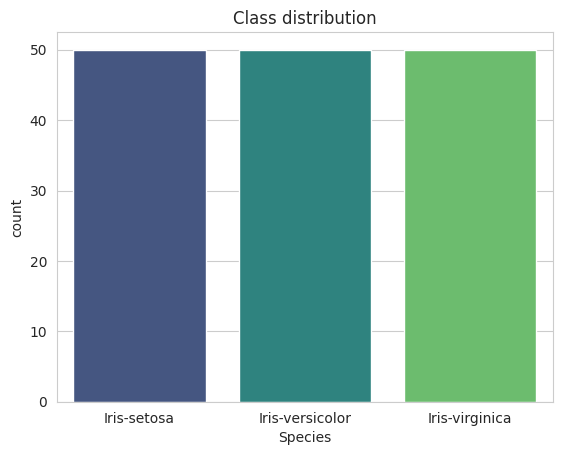

In [ ]:
sns.countplot(x="Species", data=df, palette="viridis")
plt.title("Class distribution")
plt.show()


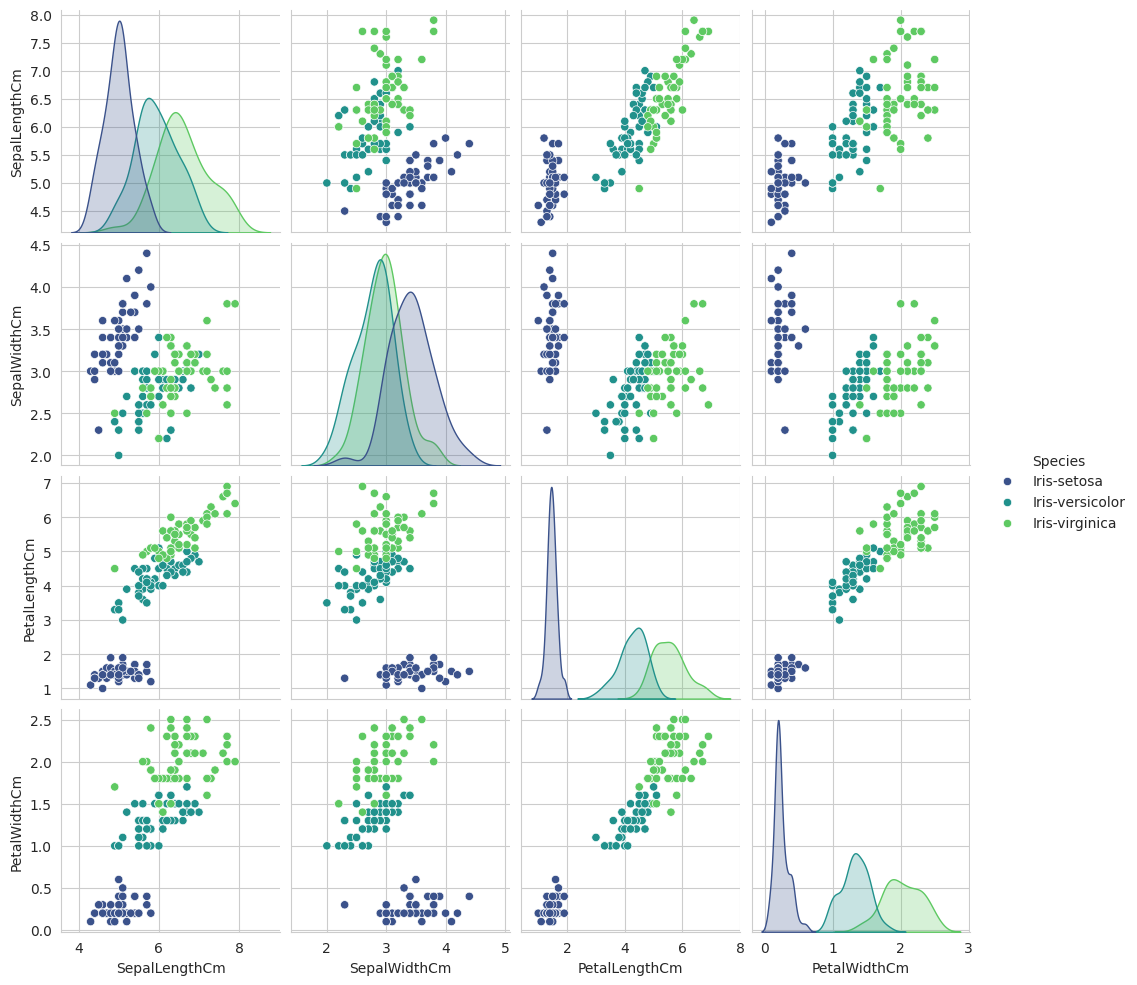

In [ ]:
sns.pairplot(df, hue="Species", palette="viridis")
plt.show()


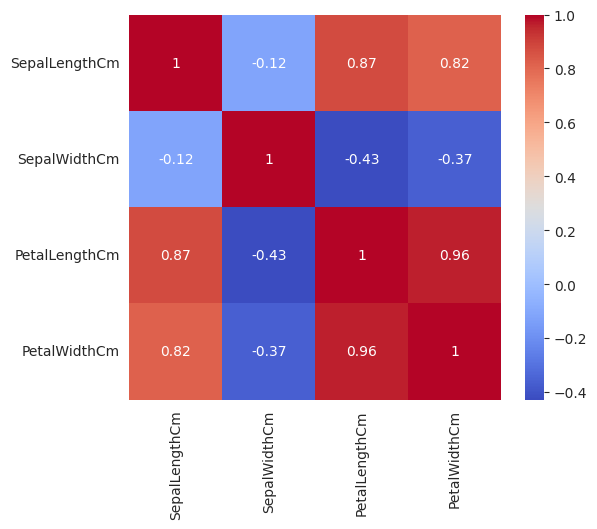

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(df.drop(columns="Species").corr(), annot=True, cmap="coolwarm")
plt.show()


/tmp/ipykernel_2760/4148974038.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Species", y=col, data=df, palette="viridis", ax=ax)
/tmp/ipykernel_2760/4148974038.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Species", y=col, data=df, palette="viridis", ax=ax)
/tmp/ipykernel_2760/4148974038.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Species", y=col, data=df, palette="viridis", ax=ax)
/tmp/ipykernel_2760/4148974038.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in 

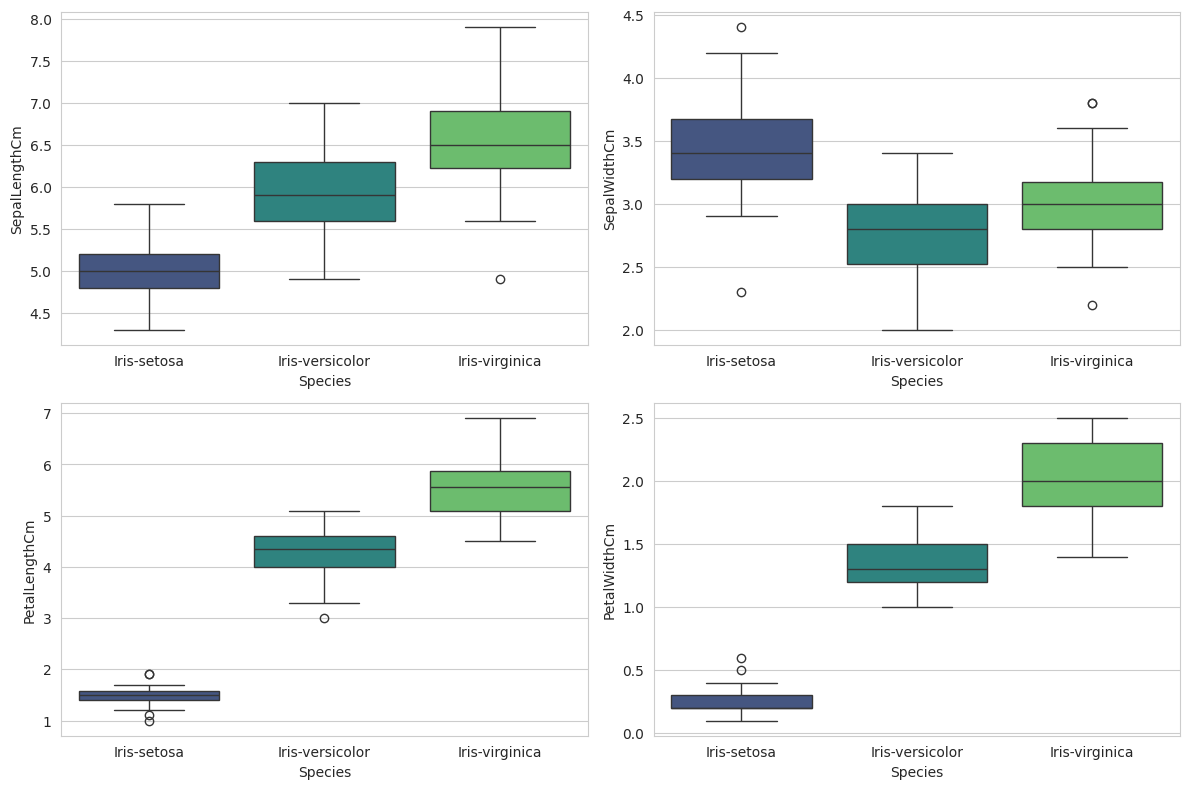

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
for ax, col in zip(axes.flatten(), features):
    sns.boxplot(x="Species", y=col, data=df, palette="viridis", ax=ax)
plt.tight_layout()
plt.show()


Petal length and width separate the classes best, setosa especially. Sepal features overlap more between versicolor and virginica.

## Prep data

In [ ]:
le = LabelEncoder()
df["target"] = le.fit_transform(df["Species"])

X = df[features].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Train models

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

logreg = LogisticRegression(max_iter=200)
logreg.fit(X_train_scaled, y_train)
logreg_pred = logreg.predict(X_test_scaled)

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)


In [ ]:
models = {
    "k-NN": (knn, knn_pred, X_train_scaled),
    "Logistic Regression": (logreg, logreg_pred, X_train_scaled),
    "Decision Tree": (tree, tree_pred, X_train),
}

for name, (model, pred, X_cv) in models.items():
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average="macro")
    rec = recall_score(y_test, pred, average="macro")
    cv = cross_val_score(model, X_cv, y_train, cv=5).mean()
    print(f"{name}: acc={acc:.3f}, precision={prec:.3f}, recall={rec:.3f}, cv={cv:.3f}")


k-NN: acc=0.933, precision=0.944, recall=0.933, cv=0.967
Logistic Regression: acc=0.933, precision=0.933, recall=0.933, cv=0.958
Decision Tree: acc=0.933, precision=0.933, recall=0.933, cv=0.942


## Confusion matrices

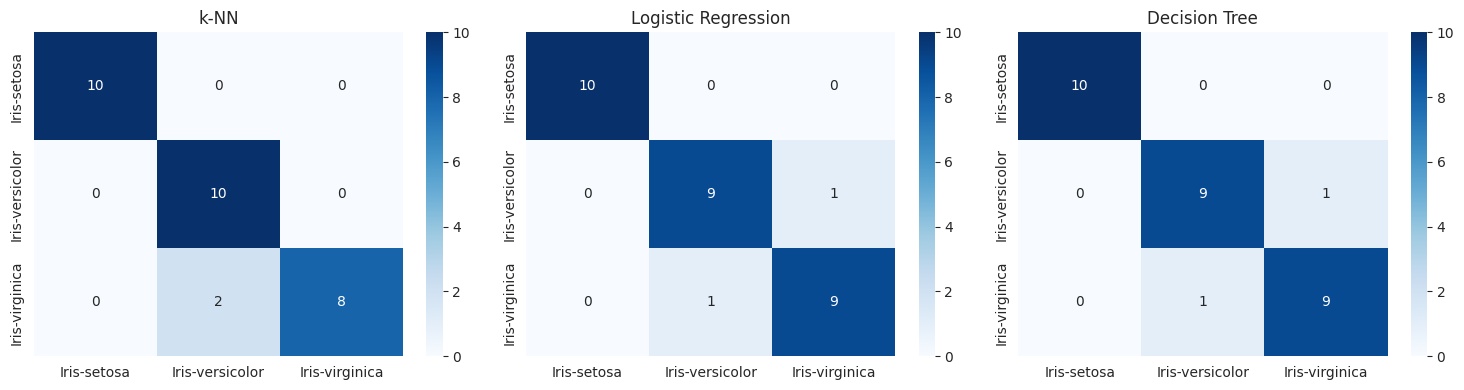

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (model, pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()


In [ ]:
for name, (model, pred, _) in models.items():
    print(name)
    print(classification_report(y_test, pred, target_names=le.classes_))


k-NN
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30

Logistic Regression
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

Decision Tree
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      

Logistic Regression and k-NN come out slightly ahead of the Decision Tree on this split, though all three are close given how separable the classes are.

## Save the best model

In [ ]:
best_name = max(models, key=lambda n: accuracy_score(y_test, models[n][1]))
best_model = models[best_name][0]
uses_scaling = best_name in ("k-NN", "Logistic Regression")

print("Best model:", best_name)


Best model: k-NN


In [ ]:
joblib.dump(best_model, "iris_model.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(le, "label_encoder.joblib")


In [ ]:
from google.colab import files
files.download("iris_model.joblib")
files.download("scaler.joblib")
files.download("label_encoder.joblib")


## Inference example

In [ ]:
def predict_species(sepal_length, sepal_width, petal_length, petal_width):
    model = joblib.load("iris_model.joblib")
    scaler = joblib.load("scaler.joblib")
    encoder = joblib.load("label_encoder.joblib")

    x = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    x = scaler.transform(x)
    pred = model.predict(x)[0]
    return encoder.inverse_transform([pred])[0]


predict_species(5.1, 3.5, 1.4, 0.2)


Note: if the best model ends up being the Decision Tree, skip the `scaler.transform(x)` line above since it was trained on unscaled data.